# Fake Product Review Detection
## Part 1 — Data Loading, EDA & Text Preprocessing

This notebook covers:
1. Library imports and data loading
2. Exploratory Data Analysis (EDA)
3. Text cleaning and preprocessing
4. Saving the preprocessed dataset for Part 2

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings, string
import string
import nltk
from nltk.tokenize import regexp_tokenize
from nltk.corpus import stopwords
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Tarun\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Tarun\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tarun\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Tarun\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tarun\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Load Dataset

In [ ]:
df = pd.read_csv('Data Sets/Raw_Dataset.csv')
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


## 2. Exploratory Data Analysis (EDA)

In [ ]:
df.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [ ]:
df.describe()

,rating
count,40432.000000
mean,4.256579
std,1.144354
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
df['rating'].value_counts()

rating
5.0    24559
4.0     7965
3.0     3786
1.0     2155
2.0     1967
Name: count, dtype: int64

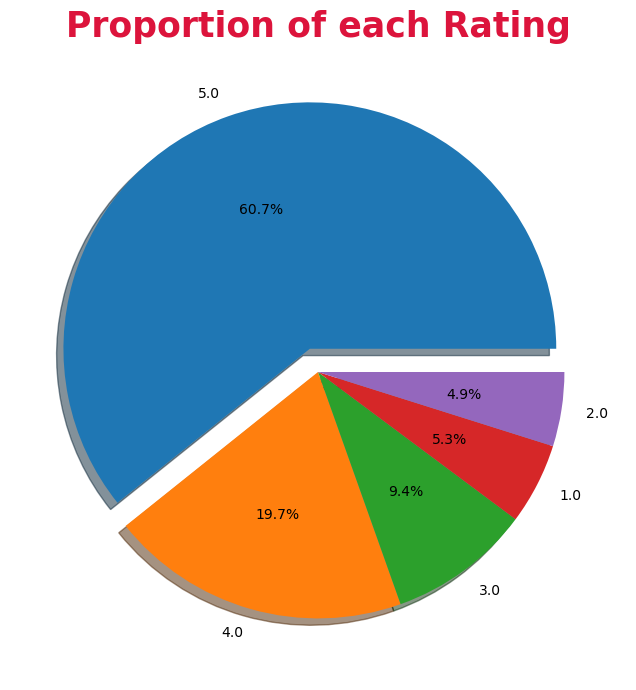

In [ ]:
plt.figure(figsize=(15, 8))
labels = df['rating'].value_counts().keys()
values = df['rating'].value_counts().values
explode = (0.1, 0, 0, 0, 0)
plt.pie(values, labels=labels, explode=explode, shadow=True, autopct='%1.1f%%')
plt.title('Proportion of each Rating', fontweight='bold', fontsize=25, pad=20, color='crimson')
plt.show()

In [ ]:
# Label distribution: OR = Original/Genuine, CG = Computer Generated/Fake
df['label'].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

## 3. Text Preprocessing

We apply the following pipeline to the `text_` column:
1. **Tokenize** using NLTK
2. **Remove** stopwords, digits, and punctuation
3. **Lowercase** the text
4. **Lemmatize** words using `WordNetLemmatizer`

> **Note:** We use only lemmatization (not stemming). Lemmatization is linguistically accurate and produces real words, making it more suitable for NLP classification tasks. Applying stemming *after* lemmatization is counterproductive because stemming mangles already-clean tokens.

In [ ]:
stop_words = set(stopwords.words('english'))
punctuation_set = set(string.punctuation)

def preprocess_fast(text):

    tokens = regexp_tokenize(str(text).lower(), r'\w+')

    clean_words = [
        word for word in tokens 
        if word not in stop_words 
        and not word.isdigit()
        and word not in punctuation_set
    ]
    
    return ' '.join(clean_words)


In [ ]:
df['text_'] = df['text_'].apply(preprocess_fast)

In [ ]:
# Lowercase the text
df['text_'] = df['text_'].str.lower()

In [ ]:
# Lemmatize words — converts inflected forms to their base/dictionary form
# e.g. 'running' → 'run', 'studies' → 'study'
lemmatizer = WordNetLemmatizer()

def lemmatize_words(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in str(text).split()])

df['text_'] = df['text_'].apply(lemmatize_words)

In [ ]:
# Preview preprocessed text
df['text_'].head()

0    love well made sturdy comfortable love pretty
1     love great upgrade original mine couple year
2          pillow saved back love look feel pillow
3      missing information use great product price
4              nice set good quality set two month
Name: text_, dtype: object

## 4. Save Preprocessed Dataset

In [ ]:
output_dir = 'Data Sets'
output_file = os.path.join(output_dir, 'Preprocessed_Dataset.csv')
os.makedirs(output_dir, exist_ok=True)
df.to_csv(output_file, index=False)
print(f"Saved: {output_file}")
print('Shape:', df.shape)

Saved: Data Sets\Preprocessed_Dataset.csv
Shape: (40432, 4)
